# 12 Not the Widest Line

| | |
|---|---|
| **Path** | Perceptron |
| **Prerequisite** | 11 |

The two perceptrons have the same tightness. For $(2, 1, -1)$ the smallest margin is C's margin, which is $1$, and the weight square is

$$
\lVert(2, 1)\rVert^{2} = 4 + 1 = 5
$$

The squared geometric margin is the squared functional margin divided by that weight square:

$$
\dfrac{1^{2}}{5} = \dfrac{1}{5}
$$

For $(1, 2, -1)$ the same arithmetic gives $1/5$ again.

A third line puts the boundary halfway from C to the two pass papers. A and B both have coordinate sum $3$, and C has sum $0$. The halfway level is $3/2$:

$$
s = x_1 + x_2 - \dfrac{3}{2}
$$

Every training margin equals $3/2$:

$$
\begin{aligned}
m(A) &= 2 + 1 - \dfrac{3}{2} = \dfrac{3}{2} \\
m(B) &= \dfrac{3}{2} \\
m(C) &= (-1)\left(-\dfrac{3}{2}\right) = \dfrac{3}{2}
\end{aligned}
$$

The weight square is $\lVert(1, 1)\rVert^{2} = 2$, so the squared geometric margin is

$$
\dfrac{(3/2)^{2}}{2} = \dfrac{9/4}{2} = \dfrac{9}{8}
$$

And

$$
\dfrac{9}{8} > \dfrac{1}{5}
$$

because $9\cdot 5 = 45$ and $8\cdot 1 = 8$. The halfway line leaves a wider street. The perceptron never looked for it. It stopped at the first street that made every training margin positive.

The widest street is the subject of the support-vector path. Nothing in the update rule of this path asks for it.


## Example 1 — Compare the two squared margins

### Predict

The cell prints `1/5` and `9/8`, then confirms `9/8` is larger.


In [1]:
# Perceptron squared margin 1/5. Halfway line squared margin 9/8.
from fractions import Fraction

perceptron = Fraction(1, 5)
widest = Fraction(3, 2) ** 2 / 2
print(perceptron, widest)
assert widest == Fraction(9, 8)
assert widest > perceptron
assert 9 * 5 > 8 * 1


1/5 9/8


## Example 2 — The picture of the three lines

A and B passed. C failed. The blue segment is $2x_1 + x_2 = 1$, the order that met A first. The ink segment is $x_1 + 2x_2 = 1$, the order that met B first. The gray segment is the wider line $x_1 + x_2 = 3/2$. The open circle is the unseen paper $(0, 1)$: it sits on the blue segment.


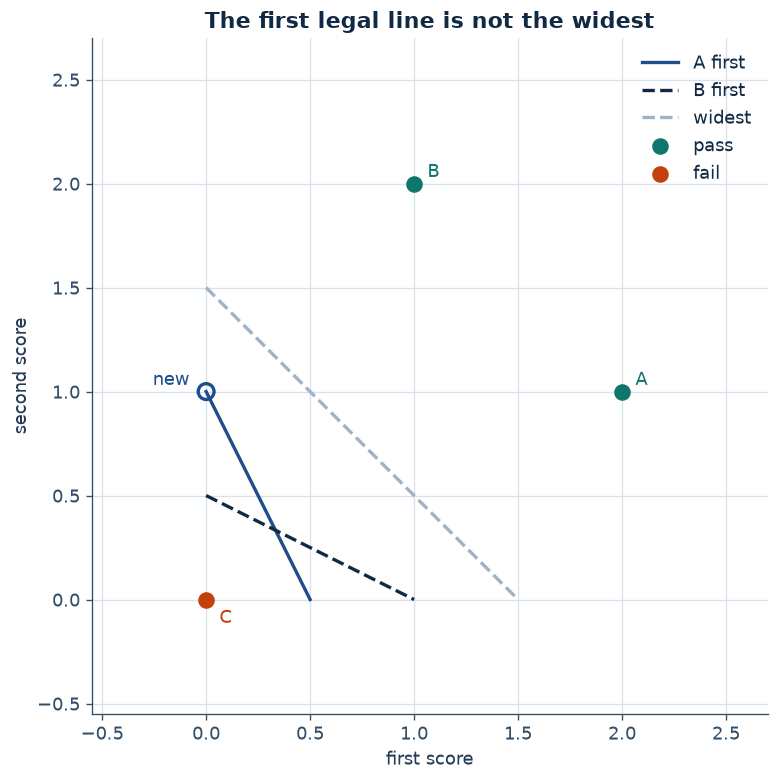

In [2]:
import matplotlib.pyplot as plt

# Pass is green, fail is clay, and a learned line is blue.
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#d9e2ec",
    "axes.edgecolor": "#334e68",
    "axes.labelcolor": "#243b53",
    "xtick.color": "#334e68",
    "ytick.color": "#334e68",
    "text.color": "#102a43",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 11,
})
BLUE = "#1d4e89"
CLAY = "#c2410c"
GREEN = "#0f766e"
INK = "#102a43"
GRAY = "#9fb3c8"

# Three legal lines. The gray one leaves the wider street. (0, 1) lies on the blue line.
fig, ax = plt.subplots(figsize=(7.2, 6.4), constrained_layout=True)
ax.plot([0, 0.5], [1, 0], color=BLUE, linewidth=2, label="A first")
ax.plot([0, 1], [0.5, 0], color=INK, linewidth=2, linestyle="--", label="B first")
ax.plot([0, 1.5], [1.5, 0], color=GRAY, linewidth=2, linestyle="--", label="widest")
ax.scatter([2, 1], [1, 2], s=80, color=GREEN, zorder=3, label="pass")
ax.scatter([0], [0], s=80, color=CLAY, zorder=3, label="fail")
ax.scatter([0], [1], s=90, facecolors="none", edgecolors=BLUE, linewidths=2, zorder=4)
ax.annotate("A", (2, 1), textcoords="offset points", xytext=(8, 4), color=GREEN)
ax.annotate("B", (1, 2), textcoords="offset points", xytext=(8, 4), color=GREEN)
ax.annotate("C", (0, 0), textcoords="offset points", xytext=(8, -14), color=CLAY)
ax.annotate("new", (0, 1), textcoords="offset points", xytext=(-32, 4), color=BLUE)
ax.set_xlim(-0.55, 2.7)
ax.set_ylim(-0.55, 2.7)
ax.set_aspect("equal")
ax.set_xlabel("first score")
ax.set_ylabel("second score")
ax.set_title("The first legal line is not the widest")
ax.legend(frameon=False, loc="upper right")


## Pitfall — Equal training success is not equal geometry

All three lines get the three papers strictly correct. A count of training mistakes cannot see the difference between $1/5$ and $9/8$. The difference is the distance from the nearest paper to the line, and that distance uses the length of the weight vector.


## Summary

The walks of Lessons 07 and 11 each finish with squared geometric margin $1/5$. The line $x_1 + x_2 = 3/2$ has squared geometric margin $9/8$, which is larger. The perceptron stops when the margins become positive. It does not compare streets.
